In [57]:
from tensorflow.keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(
    num_words=10000)

In [58]:
word_index = imdb.get_word_index()
reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()])
decoded_review = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[0]])

In [59]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [60]:
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

In [61]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

model = keras.Sequential([
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
    layers.Dropout(0.4),
    layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
    layers.Dropout(0.4),
    layers.Dense(1, activation="sigmoid")
])

In [62]:
optimizer = keras.optimizers.Adam(learning_rate = 0.00003)
model.compile(optimizer= optimizer,
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [63]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [64]:
history = model.fit(partial_x_train,
                    partial_y_train, 
                    epochs=200,
                    batch_size=128,
                    validation_data=(x_val, y_val))

Epoch 1/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.4973 - loss: 9.1323 - val_accuracy: 0.5342 - val_loss: 7.6523
Epoch 2/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5144 - loss: 7.2074 - val_accuracy: 0.6111 - val_loss: 5.9425
Epoch 3/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5327 - loss: 5.5693 - val_accuracy: 0.6817 - val_loss: 4.5169
Epoch 4/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5666 - loss: 4.2139 - val_accuracy: 0.7322 - val_loss: 3.3746
Epoch 5/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6022 - loss: 3.1439 - val_accuracy: 0.7659 - val_loss: 2.5150
Epoch 6/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6403 - loss: 2.3557 - val_accuracy: 0.7903 - val_loss: 1.9332
Epoch 7/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6691 - loss: 1.8474 - val_accuracy: 0.7964 - val_loss: 1.6258
Epoch 8/200
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6884 - loss: 1.6066 - val_acc

In [65]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

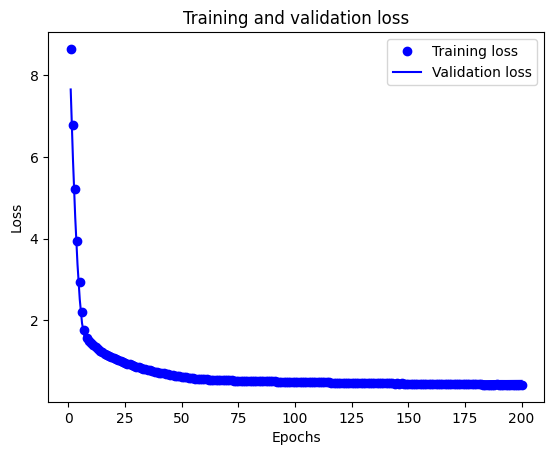

In [66]:
import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

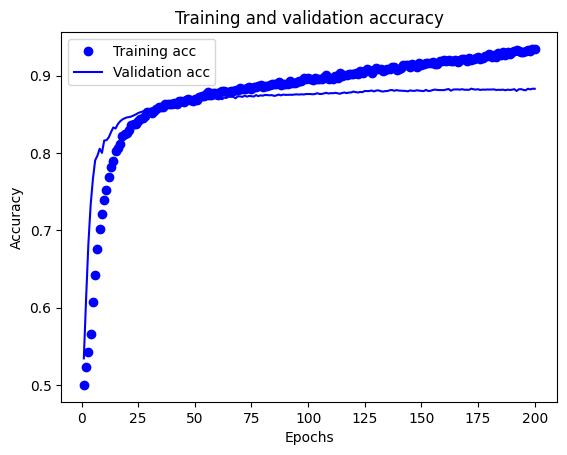

In [67]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [68]:
results = model.evaluate(x_test, y_test)
print(results)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8698 - loss: 0.5328
[0.5289557576179504, 0.8730000257492065]
